D:\py\Anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\py\Anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


⏳ Loading data...


Verbosity: 2 (Standard Logging)


⏳ Starts Training...


	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.5
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22621
CPU Count:          16
Pytorch Version:    Can't import torch
CUDA Version:       Can't get cuda version from torch
Memory Avail:       6.34 GB / 15.36 GB (41.3%)
Disk Space Avail:   156.30 GB / 313.21 GB (49.9%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=3, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 3600s
AutoGluon will save models to "C:\Users\姚景文\ag_models_3layer_safe"
Train Data Rows:    81
Train Data Columns: 14
Tuning Data Rows:    81

                     model  score_test  score_val eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0          CatBoost_BAG_L2    0.020269  -0.024833          r2        0.669128       0.734535   21.399454                 0.112193                0.085832          13.345436            2       True         19
1           XGBoost_BAG_L2    0.011384  -0.020602          r2        0.619688       0.884136   10.129675                 0.062752                0.235433           2.075657            2       True         22
2      CatBoostDeep_BAG_L2    0.011001  -0.035813          r2        0.653852       0.767508  142.457139                 0.096916                0.118806         134.403121            2       True         20
3     LightGBMLarge_BAG_L2    0.007697  -0.025069          r2        0.659981       0.765747   10.661986                 0.103045                0.117044           2.60

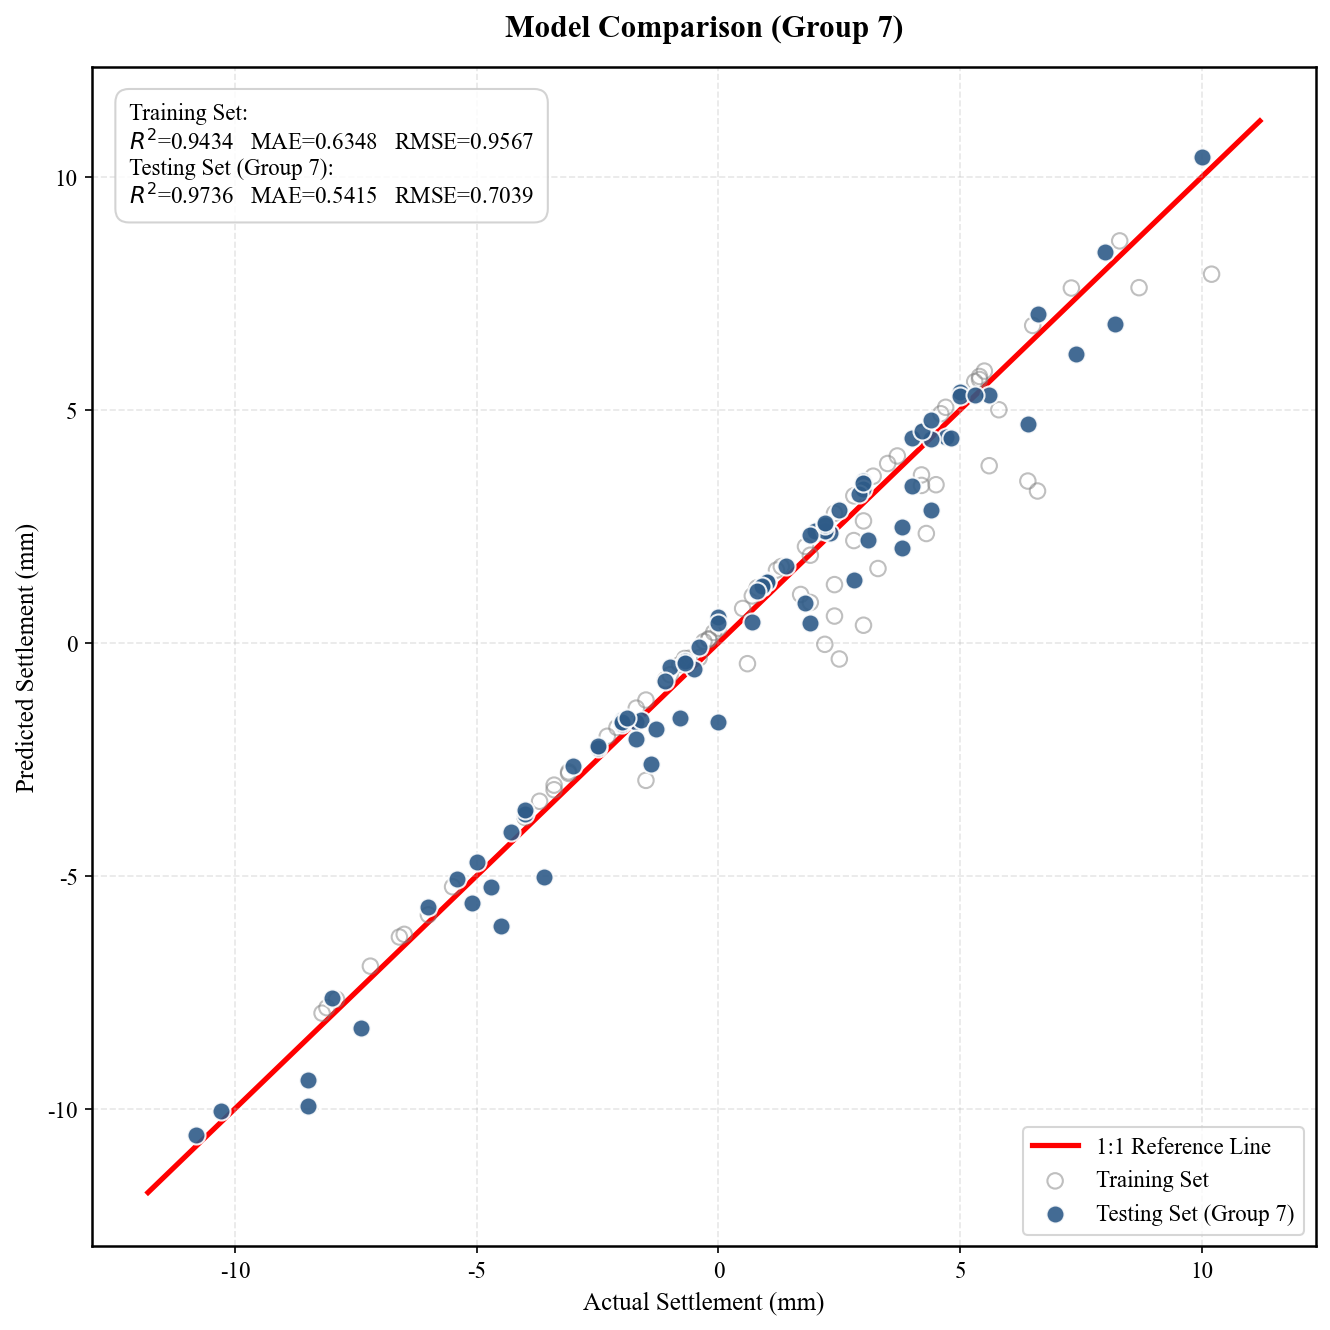

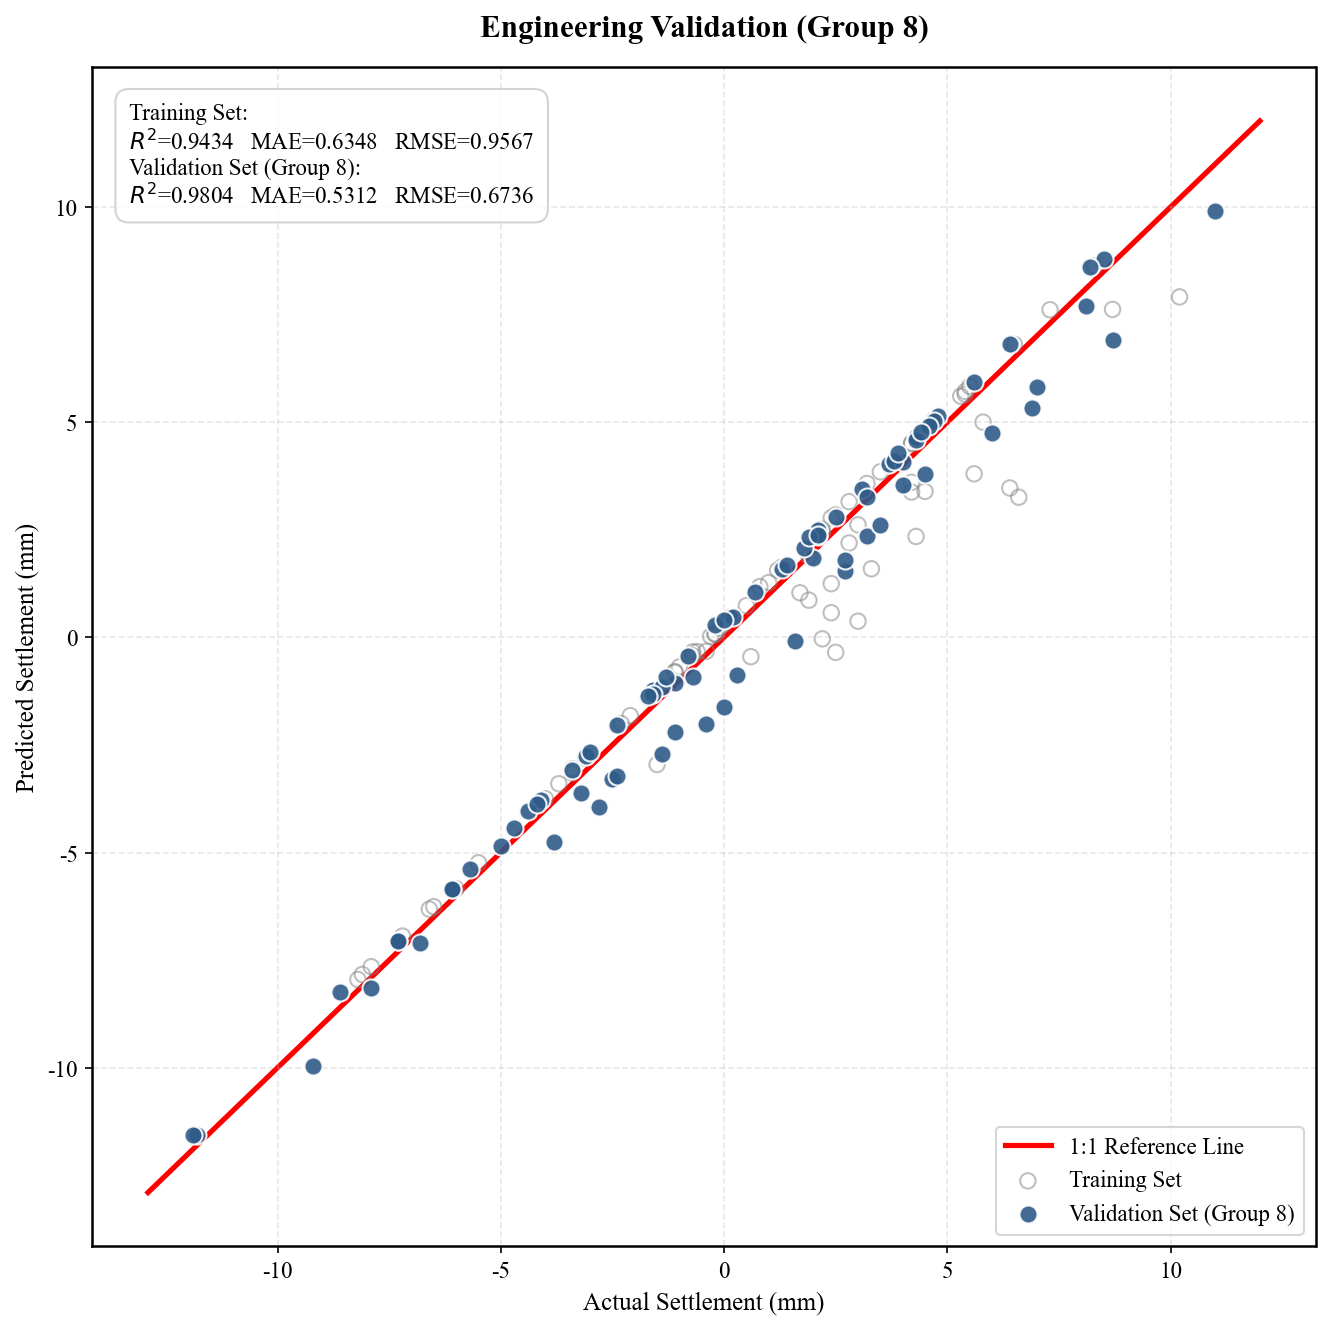

✅ 所有运行结束！


In [ ]:
import pandas as pd
import numpy as np
import random
import os
import time
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from autogluon.tabular import TabularDataset, TabularPredictor

# ==========================================
# 0. 全局配置与 SCI 绘图风格
# ==========================================
warnings.filterwarnings('ignore')
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 统一字体配置：Times New Roman
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

def set_seed(seed=2024):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
set_seed(2024)

# 万能保存函数
def universal_save_results(res_tr, res_te, res_va, model_code):
    full_df = pd.concat([res_tr, res_te, res_va], axis=0)
    full_df = full_df.sort_index()
    output_df = pd.DataFrame({'Actual': full_df['Actual_Cum'], 'Pred': full_df['Pred_Cum']})
    file_name = f"{model_code}.csv" 
    output_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"\n✅ 数据已汇总并保存至: {file_name} | 总行数: {len(output_df)}\n")

# ==========================================
# 1. 数据加载与 6-1-1 划分
# ==========================================
file_path = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"
print("⏳ Loading data...")

all_sheets = pd.read_excel(file_path, sheet_name=None)
data_list = []
for i, sheet in enumerate(all_sheets.values()):
    sheet.columns = [str(c).strip() for c in sheet.columns]
    col_map = {c: ('ID' if '编号' in c else 'Single' if '单次' in c else 'Rate' if '速率' in c else 'Cumulative' if '累计' in c else None) for c in sheet.columns}
    v_cols = {v: k for k, v in col_map.items() if v}
    if len(v_cols) >= 4:
        temp = sheet[list(v_cols.values())].copy()
        temp.columns = list(v_cols.keys())
        temp['TimeStep'] = i + 1
        data_list.append(temp)
data = pd.concat(data_list).sort_values(['ID', 'TimeStep']).reset_index(drop=True).dropna()

df_p = data.copy()
lags = 5
for col in ['Single', 'Cumulative']:
    for i in range(1, lags + 1):
        df_p[f'{col}_lag_{i}'] = df_p.groupby('ID')[col].shift(i)

df_p['Roll_Mean_3'] = df_p.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).mean())
df_p['Roll_Std_3']  = df_p.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).std())
df_p['Diff_1'] = df_p['Single_lag_1'] - df_p['Single_lag_2']

df_p = df_p.dropna().reset_index(drop=True)
df_p['Single'] = np.log1p(df_p['Single'].clip(lower=0)) 

train_data = df_p[df_p['TimeStep'] <= 6].drop(columns=['ID', 'Rate', 'Cumulative'])
test_data  = df_p[df_p['TimeStep'] == 7].drop(columns=['ID', 'Rate', 'Cumulative'])
val_data   = df_p[df_p['TimeStep'] == 8].drop(columns=['ID', 'Rate', 'Cumulative'])

# ==========================================
# 2. 模型训练 (防内核崩溃版)
# ==========================================
print("⏳ Starts Training...")
seed_val = 2024

custom_hyperparameters = {
    'GBM': [
        {'extra_trees': True, 'seed': seed_val, 'ag_args': {'name_suffix': 'XT'}}, 
        {}, 
        {'learning_rate': 0.03, 'num_leaves': 128, 'seed': seed_val, 'ag_args': {'name_suffix': 'Large'}}, 
    ],
    'CAT': [
        {'random_seed': seed_val}, 
        {'depth': 8, 'learning_rate': 0.05, 'random_seed': seed_val, 'ag_args': {'name_suffix': 'Deep'}}, 
    ],
    'XGB': [
        {'random_state': seed_val}, 
        {'max_depth': 10, 'eta': 0.01, 'random_state': seed_val, 'ag_args': {'name_suffix': 'Dense'}}, 
    ],
    'RF': [
        {'criterion': 'squared_error', 'random_state': seed_val, 'ag_args': {'name_suffix': 'MSE'}},
        {'criterion': 'absolute_error', 'random_state': seed_val, 'ag_args': {'name_suffix': 'MAE'}},
    ],
    'XT': [
        {'criterion': 'squared_error', 'random_state': seed_val, 'ag_args': {'name_suffix': 'MSE'}},
    ],
    'KNN': [
        {'weights': 'uniform', 'ag_args': {'name_suffix': 'Unif'}},
        {'weights': 'distance', 'ag_args': {'name_suffix': 'Dist'}},
    ],
    'LR': {},         
}

predictor = TabularPredictor(
    label='Single', 
    eval_metric='r2', 
    path=f'ag_models_3layer_safe' 
).fit(
    train_data, 
    tuning_data=test_data,      
    use_bag_holdout=True,       
    presets='best_quality',      
    num_stack_levels=3,          
    hyperparameters=custom_hyperparameters, 
    save_space=True,
    num_bag_folds=5,             
    num_bag_sets=1,
    ag_args_fit={'random_state': seed_val},
    # 🚨 防崩溃核心：强制要求 AutoGluon 在本地单进程串行计算 Fold，解决 Windows 下的死锁和内存爆炸！
    ag_args_ensemble={'fold_fitting_strategy': 'sequential_local'},
    verbosity=2 # 打印详细日志，不再“静默死亡”
)

leaderboard = predictor.leaderboard(val_data, silent=False)

# ==========================================
# 3. 结果处理与保存
# ==========================================
def process_results(data_in, predictor):
    df_res = data_in.copy()
    pred_log = predictor.predict(data_in)
    df_res['Actual_Cum'] = df_res['Cumulative_lag_1'] + np.expm1(df_res['Single'])
    df_res['Pred_Cum'] = df_res['Cumulative_lag_1'] + np.expm1(pred_log)
    return df_res

res_tr = process_results(train_data, predictor)
res_te = process_results(test_data, predictor)
res_va = process_results(val_data, predictor)

universal_save_results(res_tr, res_te, res_va, '02')

# ==========================================
# 4. 优化后的 1:1 Regression Plot
# ==========================================
def plot_regression_optimized(res_set1, res_set2, label2, filename, title):
    plt.figure(figsize=(9, 9), dpi=150)
    ax = plt.gca()
    y1_t, y1_p = res_set1['Actual_Cum'], res_set1['Pred_Cum']
    y2_t, y2_p = res_set2['Actual_Cum'], res_set2['Pred_Cum']
    
    def calc_metrics(t, p):
        r2 = r2_score(t, p)
        mae = mean_absolute_error(t, p)
        rmse = np.sqrt(mean_squared_error(t, p))
        return r2, mae, rmse

    m1 = calc_metrics(y1_t, y1_p)
    m2 = calc_metrics(y2_t, y2_p)
    
    axis_min = min(y1_t.min(), y2_t.min()) - 1
    axis_max = max(y1_t.max(), y2_t.max()) + 1
    
    plt.plot([axis_min, axis_max], [axis_min, axis_max], 'r-', lw=2.5, label='1:1 Reference Line', zorder=1)
    plt.scatter(y1_t, y1_p, facecolors='none', edgecolors='gray', s=55, alpha=0.5, label='Training Set', zorder=2)
    plt.scatter(y2_t, y2_p, c='#2E5B88', edgecolors='white', s=75, alpha=0.9, label=label2, zorder=3)
    
    full_info = f"Training Set:\n$R^2$={m1[0]:.4f}   MAE={m1[1]:.4f}   RMSE={m1[2]:.4f}\n{label2}:\n$R^2$={m2[0]:.4f}   MAE={m2[1]:.4f}   RMSE={m2[2]:.4f}"
    
    plt.text(0.03, 0.97, full_info, transform=ax.transAxes, fontsize=11, verticalalignment='top',
             family='Times New Roman', bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.85, edgecolor='#CCCCCC'))
    
    plt.title(title, fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Actual Settlement (mm)', fontsize=12)
    plt.ylabel('Predicted Settlement (mm)', fontsize=12)
    plt.legend(loc='lower right', frameon=True)
    plt.grid(True, linestyle='--', alpha=0.3)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('black')
        
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_regression_optimized(res_tr, res_te, 'Testing Set (Group 7)', 'Fig1_Model_Comparison.png', 'Model Comparison (Group 7)')
plot_regression_optimized(res_tr, res_va, 'Validation Set (Group 8)', 'Fig2_Engineering_Validation.png', 'Engineering Validation (Group 8)')
print("✅ 所有运行结束！")

Computing feature importance via permutation shuffling for 14 features using 81 rows with 5 shuffle sets...


🔍 Analyzing Feature Importance (Top 6 Features)...


	31.24s	= Expected runtime (6.25s per shuffle set)
	2.31s	= Actual runtime (Completed 5 of 5 shuffle sets)


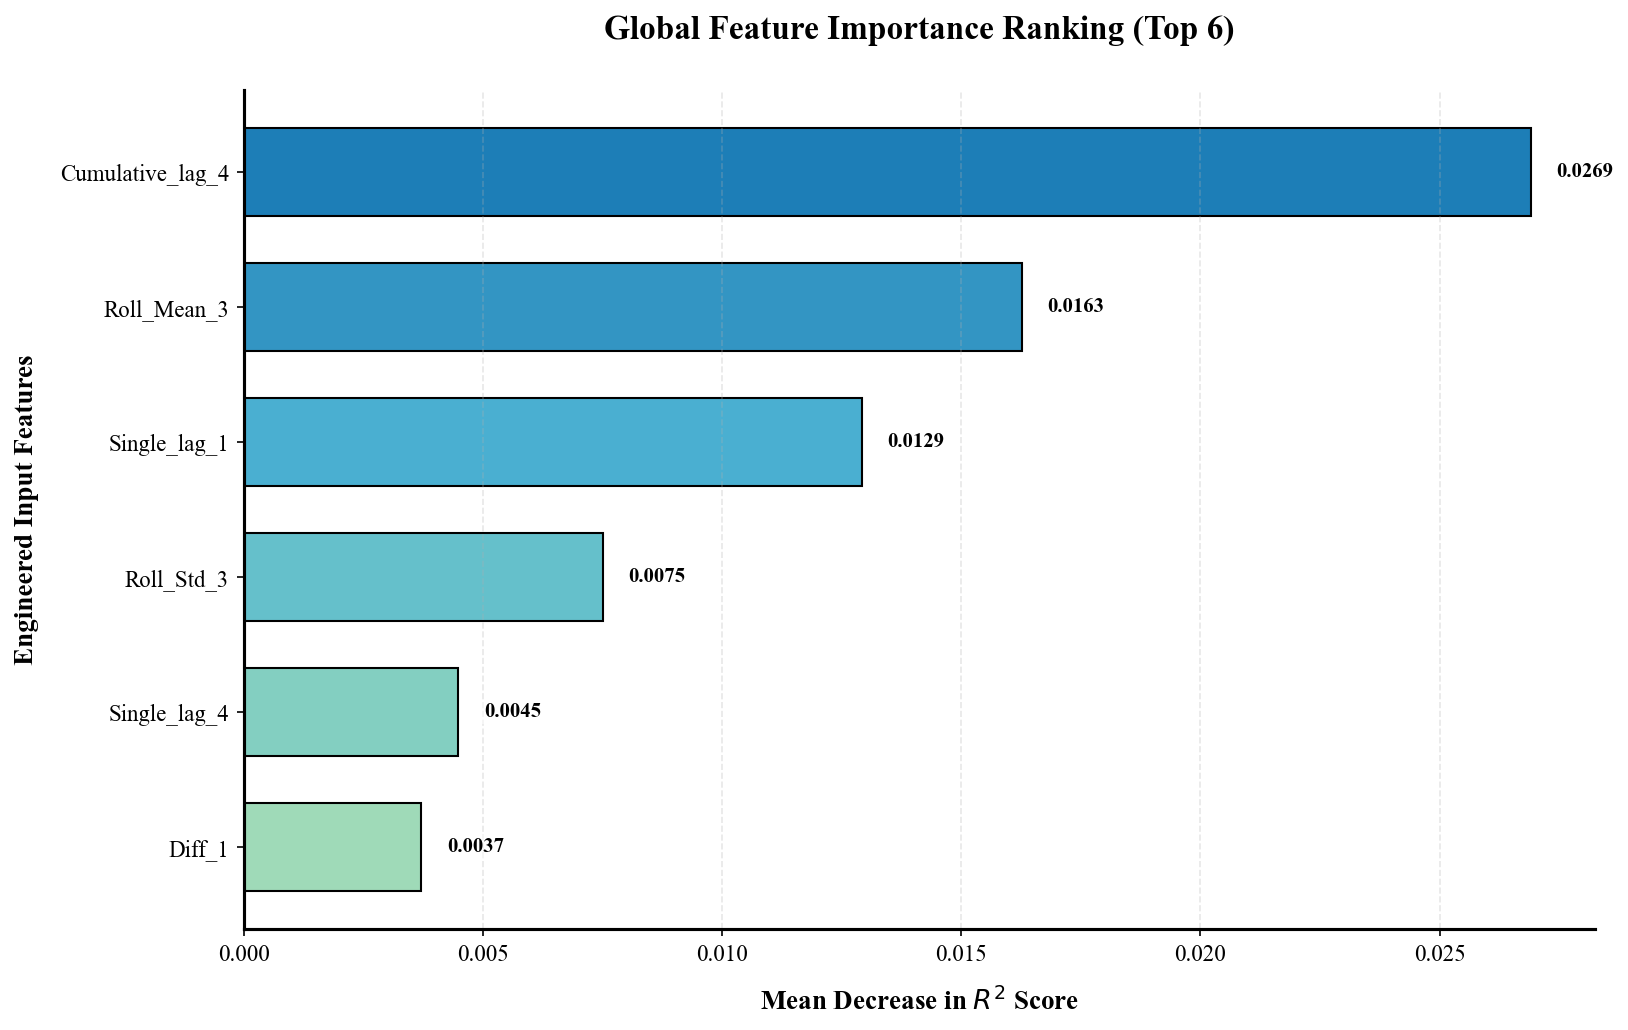

✅ Top 6 特征重要性分析图已生成。


In [2]:
# ==========================================
# 5. 特征重要性分析 (Top 6 增强版)
# ==========================================
print("🔍 Analyzing Feature Importance (Top 6 Features)...")

# 计算特征重要性 (建议使用验证集 res_te 获取更具泛化意义的权重)
importance_df = predictor.feature_importance(test_data)

# 筛选前 6 个核心特征
top_6_importance = importance_df.head(6)

# 设置绘图风格
plt.figure(figsize=(11, 7), dpi=150)
ax = plt.gca()

# 使用学术风格的渐变色 (从深蓝到青色)
colors = plt.cm.get_cmap('GnBu_r')(np.linspace(0.2, 0.6, 6))

# 绘制横向柱状图
y_pos = np.arange(len(top_6_importance))
bars = ax.barh(y_pos, top_6_importance['importance'][::-1], 
              color=colors[::-1], edgecolor='black', linewidth=1.0, height=0.65)

# 设置 Y 轴标签
ax.set_yticks(y_pos)
ax.set_yticklabels(top_6_importance.index[::-1], fontsize=11, family='Times New Roman')

# 🔴 核心改进：在柱体末端添加带背景色的数值标签，提升易读性
for bar in bars:
    width = bar.get_width()
    ax.text(width + (top_6_importance['importance'].max() * 0.02), 
            bar.get_y() + bar.get_height()/2, 
            f'{width:.4f}', 
            va='center', ha='left',
            fontsize=10, 
            family='Times New Roman',
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))

# 细节美化与 SCI 规范
ax.set_title('Global Feature Importance Ranking (Top 6)', fontsize=16, fontweight='bold', pad=25)
ax.set_xlabel('Mean Decrease in $R^2$ Score', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Engineered Input Features', fontsize=13, fontweight='bold', labelpad=10)

# 移除上方和右侧边框 (简洁风)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# 添加垂直网格线辅助对齐
plt.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('Fig3_Feature_Importance_Top6.png', bbox_inches='tight')
plt.show()

print("✅ Top 6 特征重要性分析图已生成。")

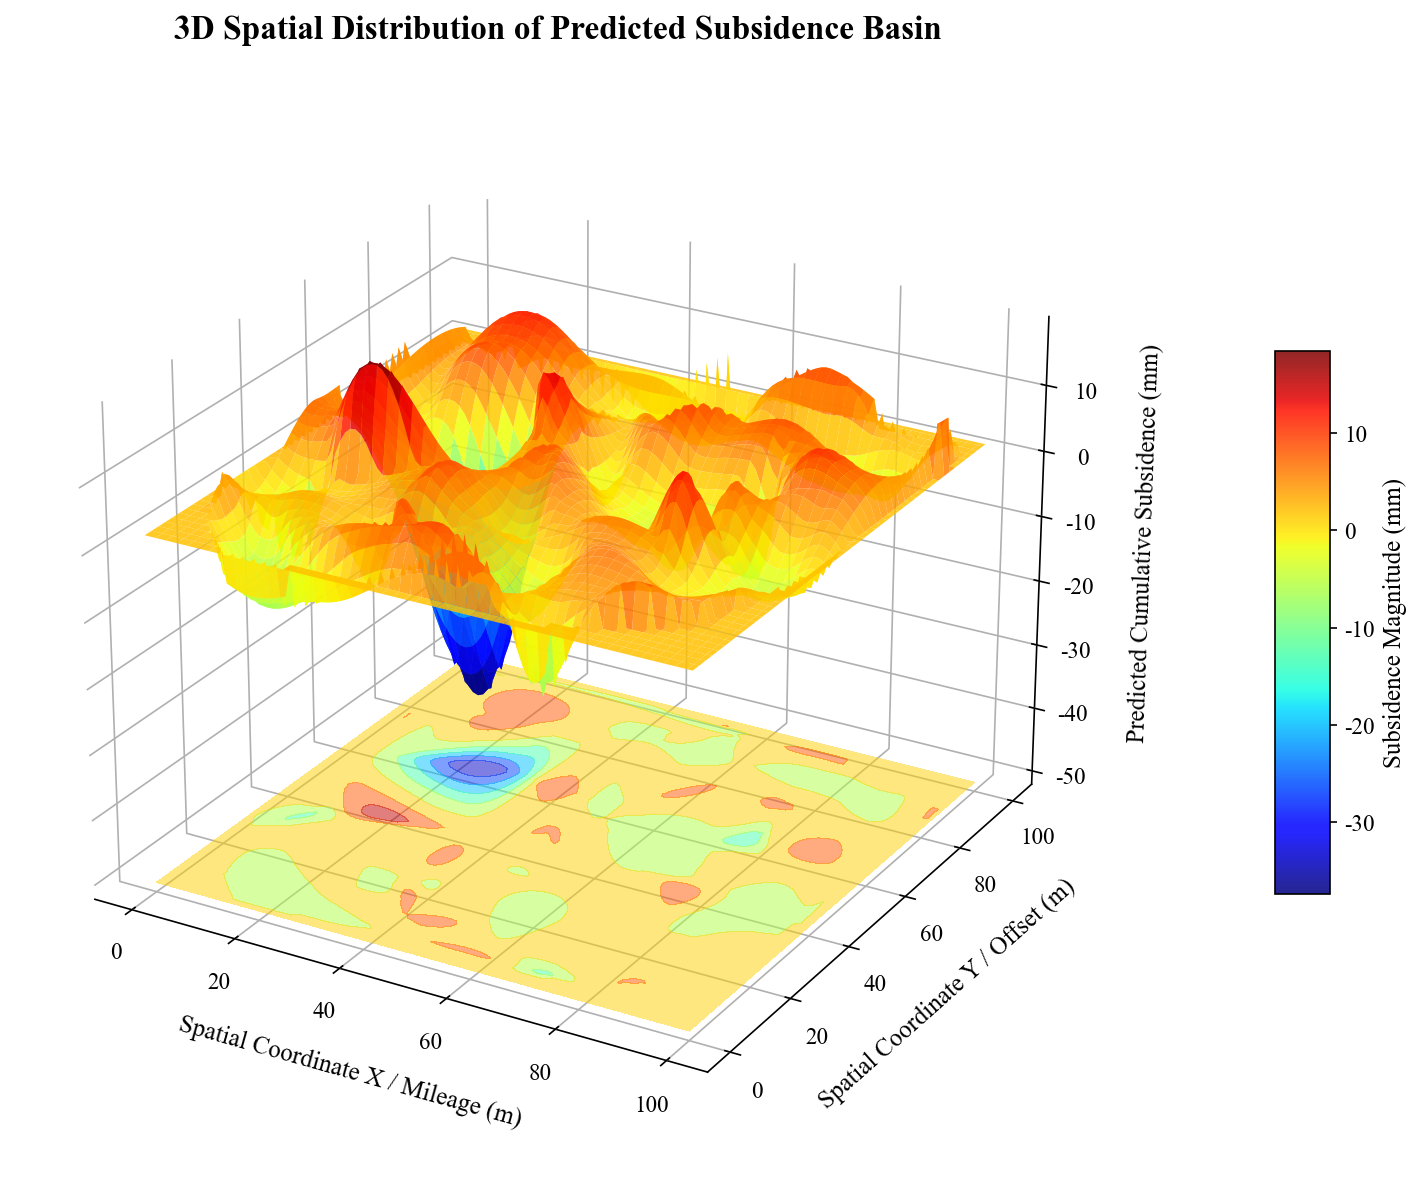

✅ 3D 地形沉降图已生成并保存为：Fig3_3D_Subsidence_Map.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.interpolate import griddata
import warnings

# 忽略警告并设置字体
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

def plot_3d_subsidence(csv_path='02.csv'):
    # 1. 读取您刚才生成的全量预测数据
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"找不到 {csv_path}，请先运行前面的预测代码生成该文件！")
        return
    
    # 获取预测的沉降值 (取绝对值以便展示下沉盆地，通常沉降是负值)
    # 为了演示，我们取前 100 个点绘制局部的 3D 沉降盆地
    z = df['Pred'].values[:100] 
    
    # 2. 构造虚拟的空间坐标 (X, Y)
    # 【注】：如果在实际工程中您有测点的真实 X, Y 坐标，请直接替换这里的 x, y！
    x = np.random.uniform(0, 100, size=len(z))  # 虚拟 X 坐标 (如：纵向里程)
    y = np.random.uniform(0, 100, size=len(z))  # 虚拟 Y 坐标 (如：横向偏移)
    
    # 将离散点插值生成平滑的网格曲面 (Meshgrid)
    grid_x, grid_y = np.mgrid[0:100:100j, 0:100:100j]
    
    # 使用 cubic 插值使得曲面更加平滑圆润，类似真实地质沉降
    grid_z = griddata((x, y), z, (grid_x, grid_y), method='cubic')
    
    # 填补 NaN 值（边缘无法插值的地方）
    grid_z = np.nan_to_num(grid_z, nan=np.nanmean(z))

    # 3. 绘制 SCI 风格的 3D 表面图
    fig = plt.figure(figsize=(12, 8), dpi=150)
    ax = fig.add_subplot(111, projection='3d')
    
    # 绘制 3D 表面 (使用 terrain 或 jet 颜色映射，彰显地质特征)
    surf = ax.plot_surface(grid_x, grid_y, grid_z, 
                           cmap=cm.jet,        # 颜色映射
                           linewidth=0,        # 网格线宽
                           antialiased=True,   # 抗锯齿
                           alpha=0.85)         # 透明度
    
    # 在底部 (zdir='z') 绘制投影等值线 (Contour)
    offset_val = np.min(grid_z) - (np.max(grid_z) - np.min(grid_z)) * 0.2
    cset = ax.contourf(grid_x, grid_y, grid_z, zdir='z', offset=offset_val, cmap=cm.jet, alpha=0.5)

    # 4. 图表细节美化
    ax.set_title('3D Spatial Distribution of Predicted Subsidence Basin', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Spatial Coordinate X / Mileage (m)', fontsize=12, labelpad=10)
    ax.set_ylabel('Spatial Coordinate Y / Offset (m)', fontsize=12, labelpad=10)
    ax.set_zlabel('Predicted Cumulative Subsidence (mm)', fontsize=12, labelpad=10)
    
    # 设置 Z 轴的显示范围，留出底部投影的空间
    ax.set_zlim(offset_val, np.max(grid_z))
    
    # 添加颜色条 (Colorbar)
    cb = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
    cb.set_label('Subsidence Magnitude (mm)', fontsize=12)
    
    # 调整视角 (仰角 25度，方位角 -60度，最适合展示盆地)
    ax.view_init(elev=25, azim=-60)
    
    # 调整背景颜色为白色 (去除默认的灰色背景，符合 SCI 纯净风格)
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    
    plt.tight_layout()
    plt.savefig('Fig3_3D_Subsidence_Map.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ 3D 地形沉降图已生成并保存为：Fig3_3D_Subsidence_Map.png")

# 执行函数
plot_3d_subsidence('02.csv')